<a href="https://colab.research.google.com/github/Jbaner/OMDSModC_Capstone_Project/blob/main/omds_modc_week1_banerjee_jayeeta_data2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

In [ ]:
datasource= "https://archive.ics.uci.edu/static/public/383/data.csv"

df_CivicalCancer = pd.read_csv(datasource, sep=',', header=0) #loading breast cancer dataset
df_CivicalCancer.sample(10, random_state=42) #printing random sample of 10 rows

In [ ]:
df_CivicalCancer = df_CivicalCancer.drop(columns=[
    "STDs: Time since first diagnosis",
    "STDs: Time since last diagnosis",
    "STDs:cervical condylomatosis",
    "STDs:AIDS"
])

In [ ]:
binary_cols = ["Smokes (packs/year)", "IUD (years)", "STDs (number)", "Hormonal Contraceptives (years)"]
df_CivicalCancer[binary_cols] = df_CivicalCancer[binary_cols].fillna(0)

In [ ]:
#df_CivicalCancer[num_cols] = df_CivicalCancer[num_cols].fillna(df_CivicalCancer[num_cols].median())
df_CivicalCancer["Number of sexual partners"] = df_CivicalCancer["Number of sexual partners"].fillna(df_CivicalCancer["Number of sexual partners"].median())
df_CivicalCancer["Num of pregnancies"] = df_CivicalCancer["Num of pregnancies"].fillna(df_CivicalCancer["Num of pregnancies"].median())
df_CivicalCancer["First sexual intercourse"] = df_CivicalCancer["First sexual intercourse"].fillna(df_CivicalCancer["First sexual intercourse"].median())
df_CivicalCancer["Smokes (packs/year)"] = df_CivicalCancer["Smokes (packs/year)"].fillna(df_CivicalCancer["Smokes (packs/year)"].median())
df_CivicalCancer["IUD (years)"] = df_CivicalCancer["IUD (years)"].fillna(df_CivicalCancer["IUD (years)"].median())
df_CivicalCancer["STDs (number)"] = df_CivicalCancer["STDs (number)"].fillna(df_CivicalCancer["STDs (number)"].median())
df_CivicalCancer["STDs: Number of diagnosis"] = df_CivicalCancer["STDs: Number of diagnosis"].fillna(df_CivicalCancer["STDs: Number of diagnosis"].median())

df_CivicalCancer["Hormonal Contraceptives (years)"] = df_CivicalCancer["Hormonal Contraceptives (years)"].fillna(df_CivicalCancer["Hormonal Contraceptives (years)"].median())
df_CivicalCancer["STDs:condylomatosis"] = df_CivicalCancer["STDs:condylomatosis"].fillna(df_CivicalCancer["STDs:condylomatosis"].median())
#df_CivicalCancer["STDs:cervical condylomatosis"] = df_CivicalCancer["STDs:cervical condylomatosis"].fillna(df_CivicalCancer["STDs:cervical condylomatosis"].median())
df_CivicalCancer["STDs:vulvo-perineal condylomatosis"] = df_CivicalCancer["STDs:vulvo-perineal condylomatosis"].fillna(df_CivicalCancer["STDs:vulvo-perineal condylomatosis"].median())
df_CivicalCancer["STDs:syphilis"] = df_CivicalCancer["STDs:syphilis"].fillna(df_CivicalCancer["STDs:syphilis"].median())
df_CivicalCancer["STDs:pelvic inflammatory disease"] = df_CivicalCancer["STDs:pelvic inflammatory disease"].fillna(df_CivicalCancer["STDs:pelvic inflammatory disease"].median())
df_CivicalCancer["STDs:genital herpes"] = df_CivicalCancer["STDs:genital herpes"].fillna(df_CivicalCancer["STDs:genital herpes"].median())
df_CivicalCancer["STDs:molluscum contagiosum"] = df_CivicalCancer["STDs:molluscum contagiosum"].fillna(df_CivicalCancer["STDs:molluscum contagiosum"].median())
#df_CivicalCancer["STDs:AIDS"] = df_CivicalCancer["STDs:AIDS"].fillna(df_CivicalCancer["STDs:AIDS"].median())
df_CivicalCancer["STDs:Hepatitis B"] = df_CivicalCancer["STDs:Hepatitis B"].fillna(df_CivicalCancer["STDs:Hepatitis B"].median())
df_CivicalCancer["STDs:HPV"] = df_CivicalCancer["STDs:HPV"].fillna(df_CivicalCancer["STDs:HPV"].median())

df_CivicalCancer["Dx:HPV"] = df_CivicalCancer["Dx:HPV"].fillna(df_CivicalCancer["Dx:HPV"].mode())
df_CivicalCancer["Dx:CIN"] = df_CivicalCancer["Dx:CIN"].fillna(df_CivicalCancer["Dx:CIN"].mode())
df_CivicalCancer["Dx:Cancer"] = df_CivicalCancer["Dx:CIN"].fillna(df_CivicalCancer["Dx:Cancer"].mode())


In [ ]:
df_CivicalCancer_nw= df_CivicalCancer[["Age","Number of sexual partners","First sexual intercourse",
                 "Num of pregnancies","Smokes (packs/year)","Hormonal Contraceptives (years)","IUD (years)","STDs (number)","STDs: Number of diagnosis",
                                    "STDs:condylomatosis", "STDs:vulvo-perineal condylomatosis",
                                    "STDs:syphilis","STDs:pelvic inflammatory disease","STDs:genital herpes",
                                    "STDs:molluscum contagiosum","STDs:Hepatitis B","STDs:HPV", "Biopsy"]]

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

#-------------------------------------------------------
# Load Dataset
#-------------------------------------------------------

df = df_CivicalCancer_nw.copy()

#-------------------------------------------------------
# Target and Features
#-------------------------------------------------------

X = df.drop(columns=["Biopsy"])
y = df["Biopsy"]

#-------------------------------------------------------
# Feature Engineering
#-------------------------------------------------------

# Polynomial features
X["Age_Sq"] = X["Age"] ** 2
X["SexualPartners_Sq"] = X["Number of sexual partners"] ** 2
X["Pregnancies_Sq"] = X["Num of pregnancies"] ** 2

# Interaction features
X["Age_SexualPartners"] = X["Age"] * X["Number of sexual partners"]
X["Smoking_Hormonal"] = X["Smokes (packs/year)"] * X["Hormonal Contraceptives (years)"]
X["STDs_TotalRisk"] = X["STDs (number)"] * X["STDs: Number of diagnosis"]

# Log transformations
X["Log_Age"] = np.log1p(X["Age"])
X["Log_Smoking"] = np.log1p(X["Smokes (packs/year)"])
X["Log_Hormonal"] = np.log1p(X["Hormonal Contraceptives (years)"])

# Risk-based composite features
X["Reproductive_Risk"] = (
    X["Number of sexual partners"] +
    X["Num of pregnancies"] +
    X["Age"]
)

X["Lifestyle_Risk"] = (
    X["Smokes (packs/year)"] +
    X["Hormonal Contraceptives (years)"]
)

X["STD_Burden"] = (
    X["STDs (number)"] +
    X["STDs: Number of diagnosis"]
)

# Additional interaction risk features
X["Age_STD_Risk"] = X["Age"] * X["STDs (number)"]
X["Smoking_STD_Risk"] = X["Smokes (packs/year)"] * X["STDs (number)"]

#-------------------------------------------------------
# Multicollinearity Check (VIF)
#-------------------------------------------------------

X_vif = sm.add_constant(X)

vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

print("\nVariance Inflation Factors:")
print(vif_data.sort_values(by="VIF", ascending=False))

#-------------------------------------------------------
# Train-Test Split
#-------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

#-------------------------------------------------------
# Linear Regression Model
#-------------------------------------------------------

model = LinearRegression()
model.fit(X_train, y_train)

#-------------------------------------------------------
# Predictions
#-------------------------------------------------------

y_pred = model.predict(X_test)

#-------------------------------------------------------
# Evaluation
#-------------------------------------------------------

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nModel Performance")
print("-----------------")
print("MSE:", mse)
print("R² Score:", r2)

#-------------------------------------------------------
# Feature Importance (Coefficients)
#-------------------------------------------------------

coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coef_df = coef_df.sort_values(by="Coefficient", ascending=False)

print("\nTop Features by Coefficient:")
print(coef_df.head(15))

#-------------------------------------------------------
# OLS Regression Summary (Statistical Insight)
#-------------------------------------------------------

X_sm = sm.add_constant(X)
ols_model = sm.OLS(y, X_sm).fit()

print("\nOLS Regression Summary")
print(ols_model.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)



Variance Inflation Factors:
                               Feature           VIF
1                                  Age           inf
2            Number of sexual partners           inf
5                  Smokes (packs/year)           inf
4                   Num of pregnancies           inf
6      Hormonal Contraceptives (years)           inf
8                        STDs (number)           inf
9            STDs: Number of diagnosis           inf
28                      Lifestyle_Risk           inf
29                          STD_Burden           inf
27                   Reproductive_Risk           inf
0                                const  1.211584e+04
24                             Log_Age  2.415425e+02
18                              Age_Sq  1.506122e+02
10                 STDs:condylomatosis  5.477757e+01
11  STDs:vulvo-perineal condylomatosis  4.235000e+01
21                  Age_SexualPartners  2.502793e+01
30                        Age_STD_Risk  1.639806e+01
20               

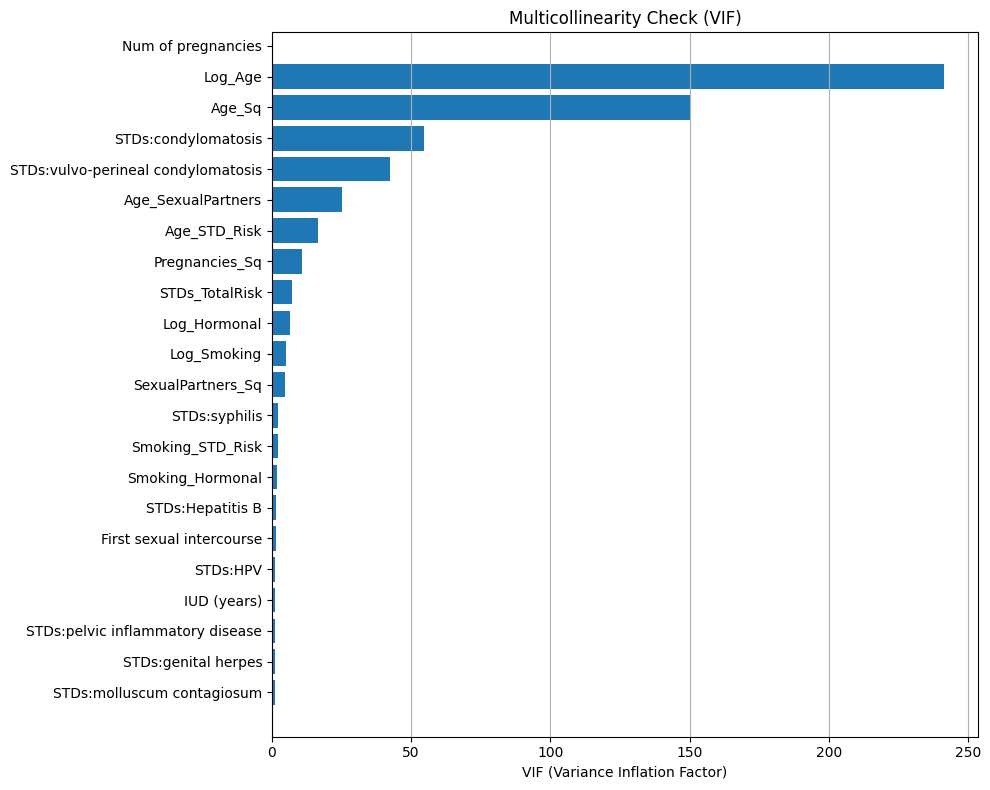

In [ ]:
#Visualize multicollinearity
import matplotlib.pyplot as plt

# Remove constant safely
vif_plot = vif_data[vif_data["Feature"] != "const"].copy()

# Sort for better visualization
vif_plot = vif_plot.sort_values("VIF", ascending=True)

plt.figure(figsize=(10, 8))

plt.barh(vif_plot["Feature"], vif_plot["VIF"])

plt.xlabel("VIF (Variance Inflation Factor)")
plt.title("Multicollinearity Check (VIF)")
plt.grid(axis='x')

plt.tight_layout()
plt.show()

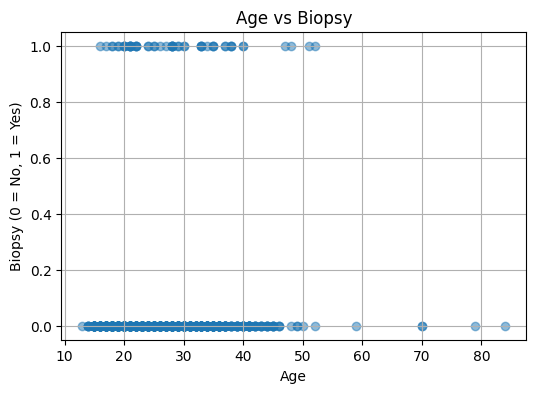

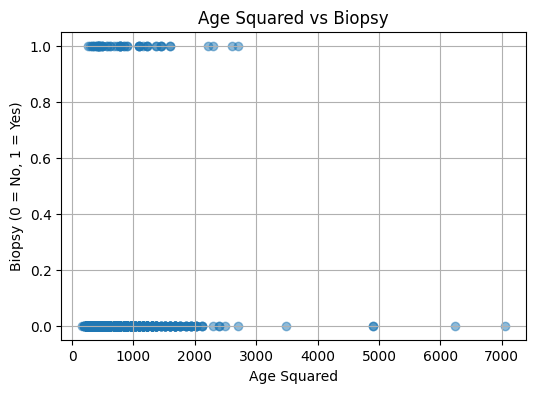

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

#-------------------------------------------------------
# Polynomial Feature Relationship (Cervical Cancer)
#-------------------------------------------------------

# Age vs Biopsy
plt.figure(figsize=(6,4))
plt.scatter(X["Age"], y, alpha=0.5)
plt.xlabel("Age")
plt.ylabel("Biopsy (0 = No, 1 = Yes)")
plt.title("Age vs Biopsy")
plt.grid(True)
plt.show()

# Age squared vs Biopsy
plt.figure(figsize=(6,4))
plt.scatter(X["Age_Sq"], y, alpha=0.5)
plt.xlabel("Age Squared")
plt.ylabel("Biopsy (0 = No, 1 = Yes)")
plt.title("Age Squared vs Biopsy")
plt.grid(True)
plt.show()

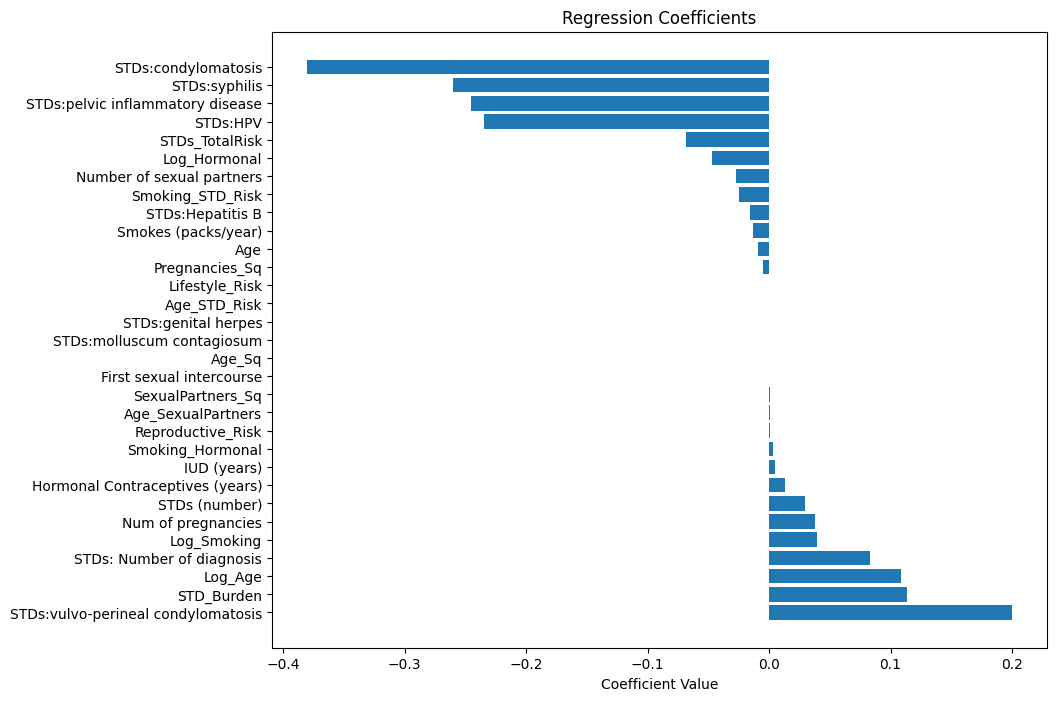

In [ ]:

#Coefficient Importance
plt.figure(figsize=(10,8))
plt.barh(coef_df["Feature"], coef_df["Coefficient"])
plt.xlabel("Coefficient Value")
plt.title("Regression Coefficients")
plt.show()